 IPL Data Analysis (2008-2024)

 *As i am learning Python in order to become a sharp data Analyst after learning basics i jumped to kaggle i downloaded the ipl data from 2008 to 2024 data and performed cleaning and codes*

In [4]:
from google.colab import files
uploaded = files.upload()


Saving deliveries.csv.zip to deliveries.csv.zip


In [7]:
import zipfile
with zipfile.ZipFile("deliveries.csv.zip" ,"r") as zip_ref:
    zip_ref.extractall(".")

In [8]:
import pandas as pd
df = pd.read_csv("deliveries.csv")
print(df.columns)
#print(df.info())
#print(df.describe())
#print(df.isnull().sum())
#print(df["batter"].nunique())
#print(df["batting_team"].nunique())

## Dataset
 #260,920 deliveries
 #673 unique batters
 #19 teams (after name cleaning)

## 1. Data Cleaning
#I noticed that in the data there were same teams with different names as they
#breaking and hiding the real insights so i made them as one
df["batting_team"] = df["batting_team"].replace({
    "Delhi Daredevils": "Delhi Capitals",
    "Rising Pune Supergiant": "Rising Pune Supergiants",
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru"
})

## 2. Top Run Scorers
#print(df.groupby("batter")["batsman_runs"].sum().sort_values(ascending = False).head())

## 3. Top player to hit Sixes
#sixes = df[df["batsman_runs"] ==  6]
#print(sixes.groupby("batter")["batsman_runs"].count().sort_values(ascending = False).head(10))

## 4. Runs scored by each IPL Teams
#print(df.groupby("batting_team")["total_runs"].sum().sort_values(ascending = False))


## 5. Wicket Takers
#print(df.groupby("bowler")["is_wicket"].sum().sort_values(ascending = False).head(10))

##6. Alone Virat Kohli Runs per oppostion teams
#print(df[df["batter"] == "V Kohli"].groupby("bowling_team")["batsman_runs"].sum())

##7. Most dangerous Batsman in Powerplay over(1-6)
#powerplay = df[df["over"] < 6]
#print(powerplay.groupby("batter")["batsman_runs"].sum().sort_values(ascending = False).head(10))

##8. Made own criteria to show the best All-Rounder of all IPL Seasons (2008-2024)
batting = df.groupby("batter")["batsman_runs"].sum()
bowling = df.groupby("bowler")["is_wicket"].sum()

#merge on player name
mvp = pd.merge(batting, bowling, left_index =True, right_index=True)
mvp_filtered = mvp[(mvp["batsman_runs"] > 200) & (mvp["is_wicket"] > 100)]
print(mvp_filtered.sort_values("batsman_runs", ascending=False).head(5))

#9. Most wickets in death overs (over>=16)
deathover = df[df["over"]>=16]
print(deathover.groupby("bowler")["is_wicket"].sum().sort_values(ascending = False).head(5))

Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')
            batsman_runs  is_wicket
SR Watson           3880        107
RA Jadeja           2959        169
AD Russell          2488        125
AR Patel            1653        131
DJ Bravo            1560        207
bowler
DJ Bravo      115
SL Malinga    104
B Kumar        93
JJ Bumrah      89
HV Patel       74
Name: is_wicket, dtype: int64


In [11]:
from google.colab import files
uploaded = files.upload()


Saving archive.zip to archive.zip


In [14]:
import zipfile
with zipfile.ZipFile("archive.zip" ,"r") as zip_ref:
    zip_ref.extractall(".")

In [ ]:
import pandas as pd
matches = pd.read_csv("matches.csv")
matches["team1"] = matches["team1"].replace({
    "Delhi Daredevils": "Delhi Capitals",
    "Rising Pune Supergiant": "Rising Pune Supergiants",
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru"
})
matches["team2"] = matches["team2"].replace({
    "Delhi Daredevils": "Delhi Capitals",
    "Rising Pune Supergiant": "Rising Pune Supergiants",
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru"
})
matches["toss_winner"] = matches["toss_winner"].replace({
    "Delhi Daredevils": "Delhi Capitals",
    "Rising Pune Supergiant": "Rising Pune Supergiants",
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru"
})
matches["winner"] = matches["winner"].replace({
    "Delhi Daredevils": "Delhi Capitals",
    "Rising Pune Supergiant": "Rising Pune Supergiants",
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru"
})
#print(matches.head())
print(matches.columns)
#print(matches.shape)
print(matches.groupby("season")["id"].count().sort_values(ascending = False))
toss_win = matches[matches["toss_winner"] == matches["winner"]]
print(f"Toss winner won the match: {len(toss_win)} out of {len(matches)}")
#print(matches.groupby("toss_winner")["winner"].count().sort_values(ascending = False))
print(matches.groupby("player_of_match")["season"].count().sort_values(ascending =False).head(10))


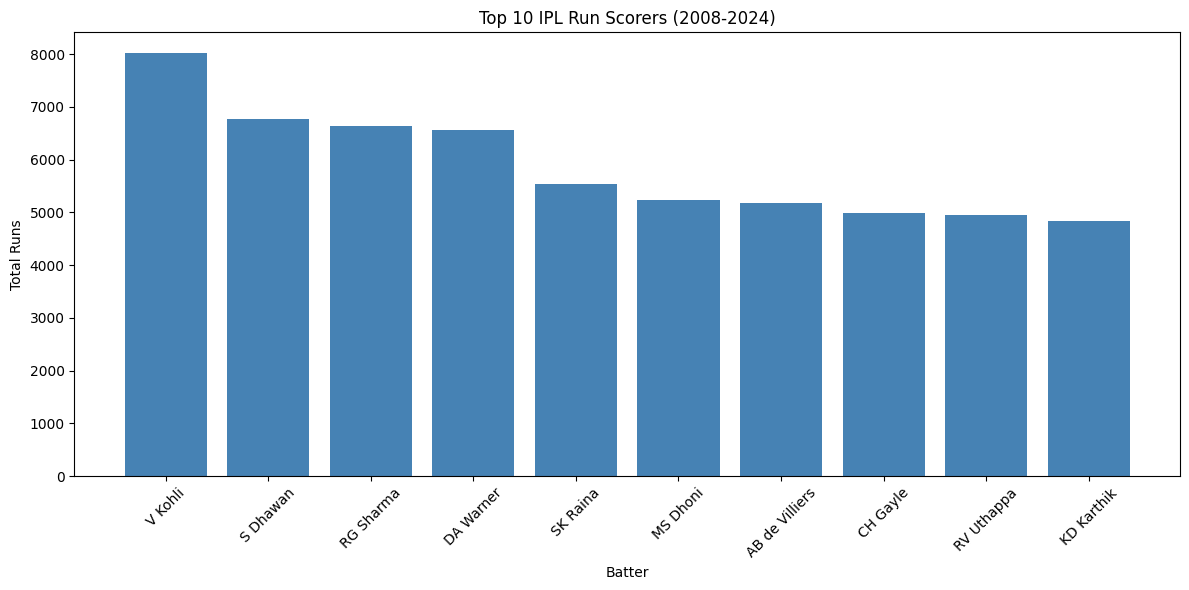

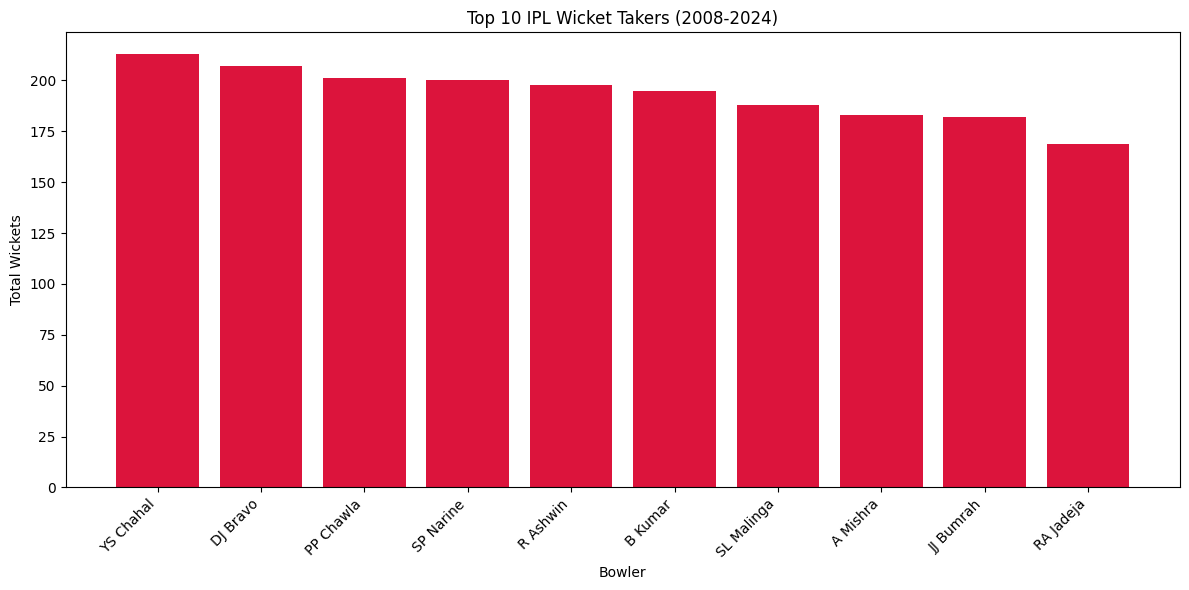

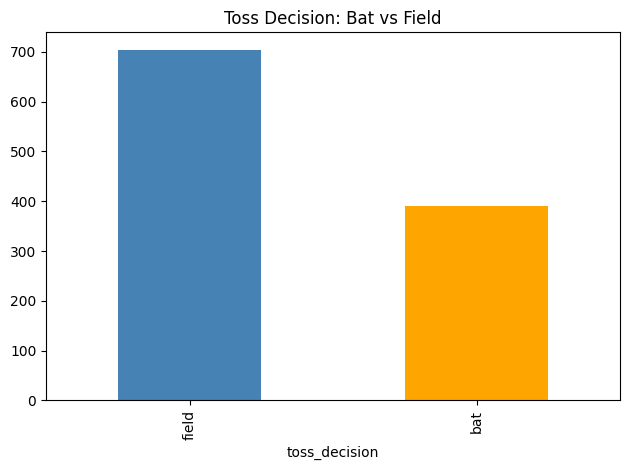

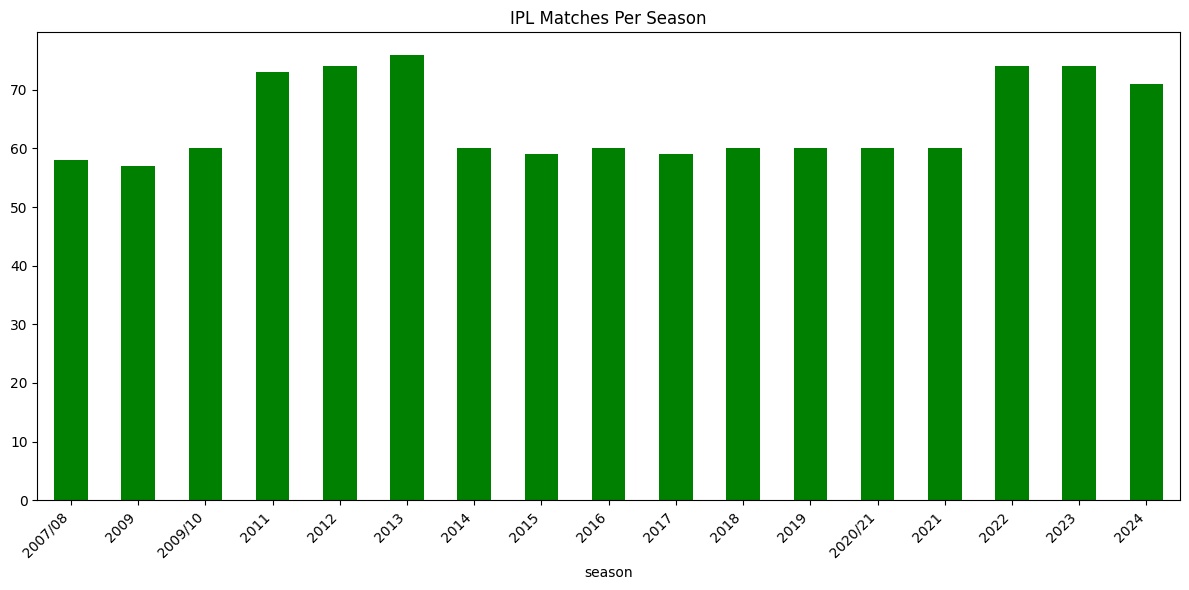

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

top_batters = df.groupby("batter")["batsman_runs"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(top_batters.index, top_batters.values, color="steelblue")
plt.title("Top 10 IPL Run Scorers (2008-2024)")
plt.xlabel("Batter")
plt.ylabel("Total Runs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


top_bowlers = df.groupby("bowler")["is_wicket"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(top_bowlers.index, top_bowlers.values, color="crimson")
plt.title("Top 10 IPL Wicket Takers (2008-2024)")
plt.xlabel("Bowler")
plt.ylabel("Total Wickets")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


matches["toss_decision"].value_counts().plot(kind="bar", color=["steelblue","orange"])
plt.title("Toss Decision: Bat vs Field")
plt.tight_layout()
plt.show()



matches.groupby("season")["id"].count().plot(kind="bar", figsize=(12,6), color="green")
plt.title("IPL Matches Per Season")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2993/1489154874.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="batsman_runs", data=df, palette="Blues_d")


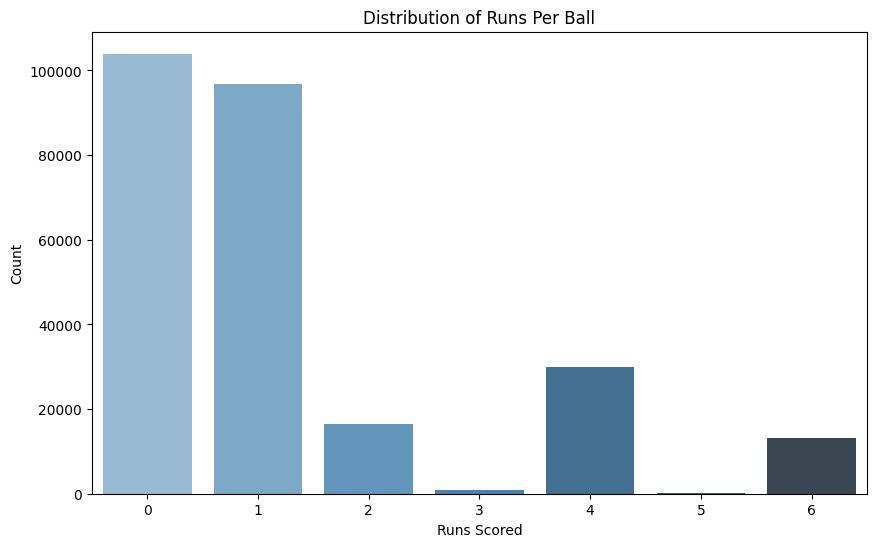

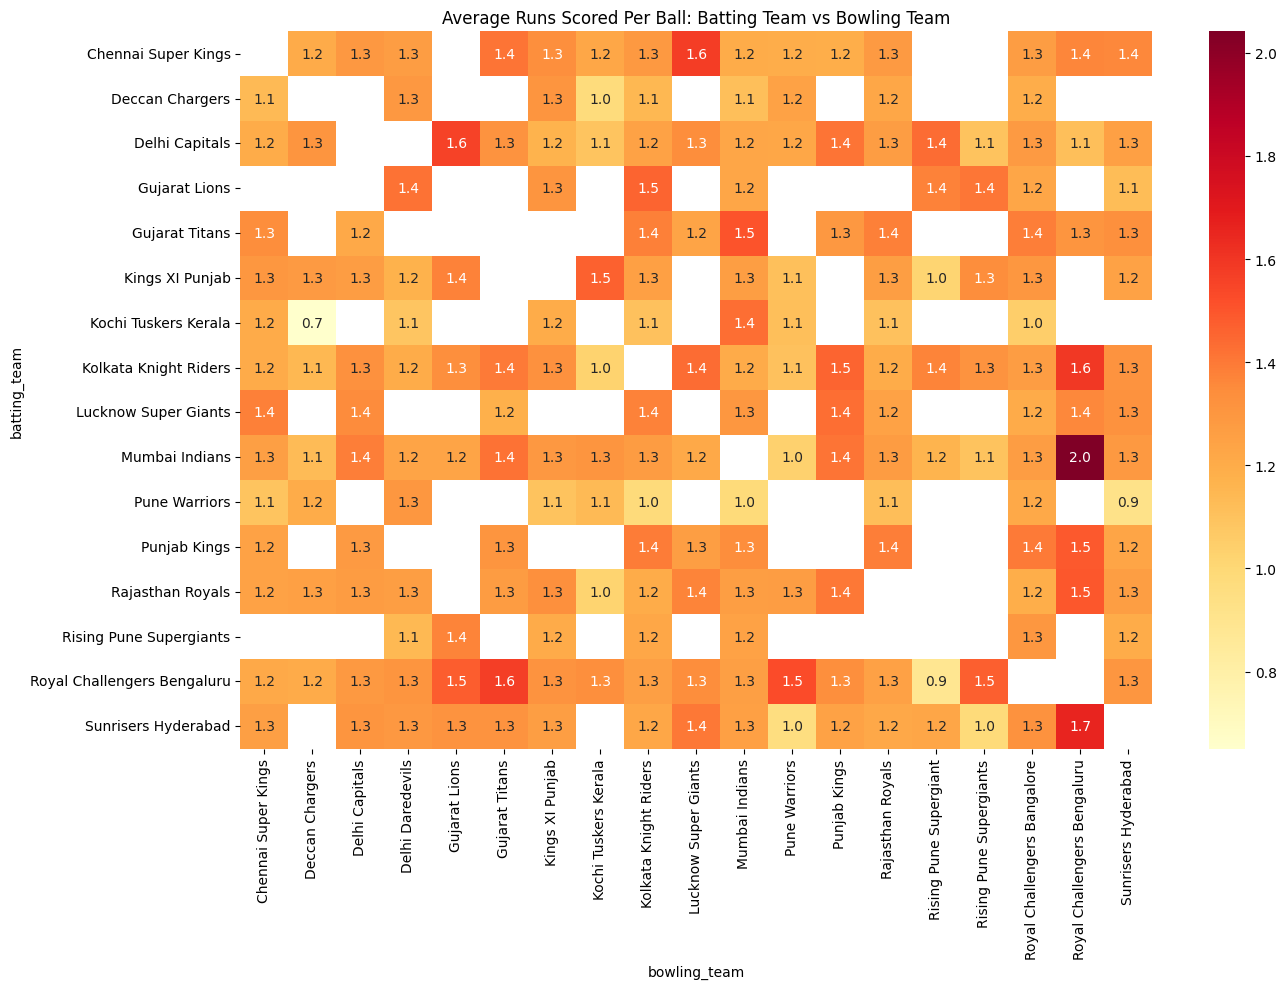

In [36]:
import seaborn as sns

# Chart 5 — runs distribution per ball
plt.figure(figsize=(10,6))
sns.countplot(x="batsman_runs", data=df, palette="Blues_d")
plt.title("Distribution of Runs Per Ball")
plt.xlabel("Runs Scored")
plt.ylabel("Count")
plt.show()

team_runs = df.groupby(["batting_team", "bowling_team"])["batsman_runs"].mean().unstack()

plt.figure(figsize=(14,10))
sns.heatmap(team_runs, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("Average Runs Scored Per Ball: Batting Team vs Bowling Team")
plt.tight_layout()
plt.show()